In [ ]:
# DEBUG: Check data structure for one file
import os
import glob

base_path = '/Users/giovanni/Papers/disc-photoevaporation-disk-radii/src/data/PLUTO_runs/'
output_dir = os.path.join(base_path, 'Rcrit_10au', 'out')
os.chdir(output_dir)

data_files = sorted(glob.glob('data.*.dbl.h5'))
last_file = data_files[-1]

print(f"Reading: {last_file}")
grid_temp = read_grid(last_file)
data_temp = read_data(last_file, grid_temp)

print(f"\nDensity info:")
print(f"  Type: {type(data_temp['density'])}")
print(f"  Shape: {data_temp['density'].shape}")
print(f"  Has units: {hasattr(data_temp['density'], 'unit')}")
if hasattr(data_temp['density'], 'unit'):
    print(f"  Unit: {data_temp['density'].unit}")
    print(f"  Value range: {data_temp['density'].value.min():.2e} to {data_temp['density'].value.max():.2e}")
else:
    print(f"  Value range: {data_temp['density'].min():.2e} to {data_temp['density'].max():.2e}")

print(f"\nGrid Z info:")
print(f"  Z shape: {grid_temp['Z'].shape}")
print(f"  Z min/max: {grid_temp['Z'].min():.2e} to {grid_temp['Z'].max():.2e} cm")

# Check for negative densities
if hasattr(data_temp['density'], 'value'):
    density_vals = data_temp['density'].value
else:
    density_vals = data_temp['density']
    
print(f"\nDensity statistics:")
print(f"  Positive values: {np.sum(density_vals > 0)}")
print(f"  Negative values: {np.sum(density_vals < 0)}")
print(f"  Zero values: {np.sum(density_vals == 0)}")
print(f"  NaN values: {np.sum(np.isnan(density_vals))}")

# Look at the data where it's negative
if np.sum(density_vals < 0) > 0:
    print(f"\nNegative density locations:")
    neg_idx = np.where(density_vals < 0)
    print(f"  Number of negative cells: {len(neg_idx[0])}")
    print(f"  Negative values range: {density_vals[neg_idx].min():.2e} to {density_vals[neg_idx].max():.2e}")

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy import constants as const
from astropy import units as u
from scipy.interpolate import griddata, RegularGridInterpolator
#from scipy.integrate import cumulative_trapezoid as cumtrapz
from tqdm import tqdm
from scipy.optimize import curve_fit

#from lmfit import Model
from functions import read_data, read_grid, remove_disc, calc_streamline, regrid, calculate_mdot_wind, save_dict

In [3]:
#os.chdir('/e/ocean1/users/picogna/Photoevaporation-OuterRadius-Project/PLUTO_runs/Rcrit_50au_wide/out/')
os.chdir('/e/ocean1/users/picogna/Photoevaporation-TransitionDiscs-Project/03Msun_30au_wider/out/')
!ls -ltr *.h5
output = 'data.0850.dbl.h5'

grid = read_grid(output)

data = read_data(output, grid)

-rw-r--r-- 1 picogna users_db 19822108 Nov  5 16:46 data.0000.dbl.h5
-rw-r--r-- 1 picogna users_db 19822108 Nov  5 17:11 data.0001.dbl.h5
-rw-r--r-- 1 picogna users_db 19822108 Nov  5 17:34 data.0002.dbl.h5
-rw-r--r-- 1 picogna users_db 19822108 Nov  5 17:56 data.0003.dbl.h5
-rw-r--r-- 1 picogna users_db 19822108 Nov  5 18:18 data.0004.dbl.h5
-rw-r--r-- 1 picogna users_db 19822108 Nov  5 18:41 data.0005.dbl.h5
-rw-r--r-- 1 picogna users_db 19822108 Nov  5 19:03 data.0006.dbl.h5
-rw-r--r-- 1 picogna users_db 19822108 Nov  6 13:33 data.0007.dbl.h5
-rw-r--r-- 1 picogna users_db 19822108 Nov  6 13:52 data.0008.dbl.h5
-rw-r--r-- 1 picogna users_db 19822108 Nov  6 14:10 data.0009.dbl.h5
-rw-r--r-- 1 picogna users_db 19822108 Nov  6 14:29 data.0010.dbl.h5
-rw-r--r-- 1 picogna users_db 19822108 Nov  6 14:48 data.0011.dbl.h5
-rw-r--r-- 1 picogna users_db 19822108 Nov  6 15:06 data.0012.dbl.h5
-rw-r--r-- 1 picogna users_db 19822108 Nov  6 15:25 data.0013.dbl.h5
-rw-r--r-- 1 picogna users_db 1982

In [4]:
# radial cell from which you trace back the mass-loss rate
DIMR = grid['X'].shape[1]
fin = DIMR - 150
print((grid['r'][0,fin]*u.cm).to(u.au))

Mstar = 0.3

data_cut, Th_cut, hole_radius = remove_disc(data, grid, Mstar, fin)

density, vr, vx, vz = regrid(data_cut, grid, res=1000)

242.1933395154997 AU


/tmp/ipykernel_75066/2280301729.py:67: RuntimeWarning: divide by zero encountered in log10
  quantity = np.log10(data['column_density'])


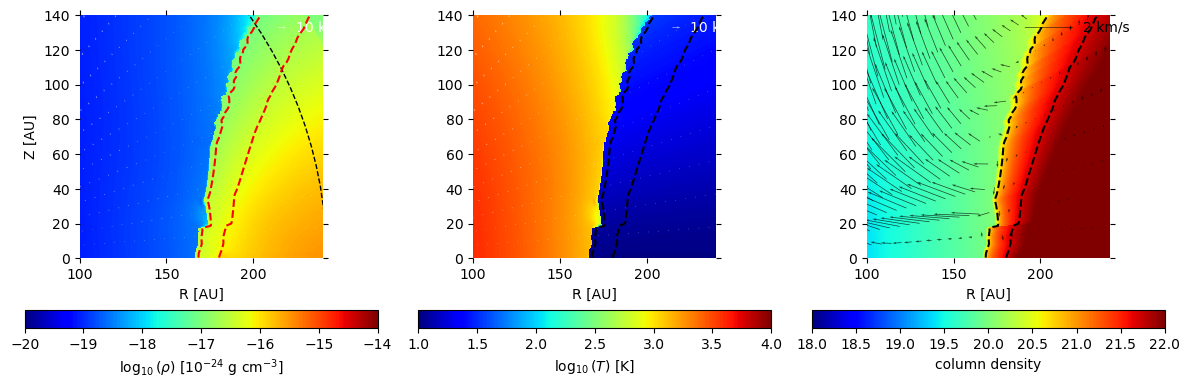

In [5]:
fig , ax  = plt.subplots(1,3,sharey=False,sharex=False,figsize=(12,4))
fig.subplots_adjust(left=.15, bottom=.16, right=.99, top=.97)

# Prepare velocity components for quiver plot
X_AU = (grid["X"]*u.cm).to(u.AU).value
Z_AU = (grid["Z"]*u.cm).to(u.AU).value
vx_kms = (data["v_x"]*u.cm/u.s).to(u.km/u.s).value
vz_kms = (data["v_z"]*u.cm/u.s).to(u.km/u.s).value

# Downsample for cleaner vector display
skip = 15  # Plot every 15th vector

for i in range(3):
    ax[i].set_xlim(100, 240)
    ax[i].set_ylim(0, 140)
    ax[i].set_aspect('equal')
    ax[i].set_xlabel('R [AU]')
    ax[i].set_ylabel('Z [AU]')
    if (i==0):
        valmin = -20
        valmax = -14
        quantity = data["density"]
        #quantity = (np.where(Cd<5.e20,quantity,np.nan))
        labelplot = '$\\log_{10}(\\rho$) [$10^{-24}$ g cm$^{-3}$]'
        plot = ax[i].pcolormesh((grid["X"]*u.cm).to(u.AU).value, (grid["Z"]*u.cm).to(u.AU).value, np.log10(quantity),
                                vmin=valmin, vmax=valmax, cmap=plt.cm.jet)
        vals = [5.e20, 5.e21]
        #plt.Circle((0, 0), (grid['r'][0,fin]*u.cm).to(u.au), ax=ax[i], color='k', fill=False)
        circle = plt.Circle((0, 0), ((grid['r'][0,fin]*u.cm).to(u.au)).value, color='k', ls='dashed', fill=False)
        ax[i].add_patch(circle)
        contours1 = ax[i].contour((grid["X"]*u.cm).to(u.AU).value ,(grid["Z"]*u.cm).to(u.AU).value,
                                  data["column_density"], vals, 
                                  linestyles = 'dashed', colors='red')
        # Add velocity vectors
        Q = ax[i].quiver(X_AU[::skip, ::skip], Z_AU[::skip, ::skip], 
                     vx_kms[::skip, ::skip], vz_kms[::skip, ::skip],
                     color='white', alpha=0.6, scale=300, width=0.003)
        # Add velocity scale legend
        ax[i].quiverkey(Q, 0.85, 0.95, 10, '10 km/s', labelpos='E', 
                       coordinates='axes', color='white', labelcolor='white')

    if (i==1):
        valmin = 1
        valmax = 4
        quantity = data["temperature_gas"]
        #quantity = (np.where(Cd<5.e20,quantity,np.nan))
        labelplot = '$\\log_{10}(T)$ [K]'
        ax[i].set_ylabel("")
        plot = ax[i].pcolormesh((grid["X"]*u.cm).to(u.AU).value, (grid["Z"]*u.cm).to(u.AU).value, 
                                np.log10(quantity),
                                vmin=valmin,vmax=valmax,cmap=plt.cm.jet)
        vals = [5.e20, 5.e21]
        contours1 = ax[i].contour((grid["X"]*u.cm).to(u.AU).value, (grid["Z"]*u.cm).to(u.AU).value,
                                data["column_density"], vals, 
                                linestyles = 'dashed', colors='black')
        # Add velocity vectors
        Q = ax[i].quiver(X_AU[::skip, ::skip], Z_AU[::skip, ::skip], 
                     vx_kms[::skip, ::skip], vz_kms[::skip, ::skip],
                     color='white', alpha=0.6, scale=300, width=0.003)
        # Add velocity scale legend
        ax[i].quiverkey(Q, 0.85, 0.95, 10, '10 km/s', labelpos='E', 
                       coordinates='axes', color='white', labelcolor='white')

    if (i==2):
        valmin = 18
        valmax = 22
        quantity = np.log10(data['column_density'])
        #quantity = np.log10(data["column_density"])
        #quantity = (np.where(Cd<5.e20,quantity,np.nan))
        labelplot = 'column density'
        ax[i].set_ylabel("")
        plot = ax[i].pcolormesh((grid["X"]*u.cm).to(u.AU).value, (grid["Z"]*u.cm).to(u.AU).value, 
                                quantity, vmin=valmin, vmax=valmax, cmap=plt.cm.jet)
        vals = [5.e20, 5.e21]
        contours1 = ax[i].contour((grid["X"]*u.cm).to(u.AU).value, (grid["Z"]*u.cm).to(u.AU).value,
                                  data["column_density"], vals, linestyles = 'dashed', colors='black')
        # Add velocity vectors
        Q = ax[i].quiver(X_AU[::skip, ::skip], Z_AU[::skip, ::skip], 
                     vx_kms[::skip, ::skip], vz_kms[::skip, ::skip],
                     color='black', alpha=0.7, scale=10, width=0.003)
        # Add velocity scale legend
        ax[i].quiverkey(Q, 0.85, 0.95, 2, '2 km/s', labelpos='E', 
                       coordinates='axes', color='black')

    fig.colorbar(plot, ax=ax[i], orientation='horizontal', label=labelplot)
    ax[i].tick_params(top='off', bottom='off', left='on', right='off', labelleft='on', labelbottom='on')
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    ax[i].spines["left"].set_visible(False)
    ax[i].spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()
plt.close(fig)

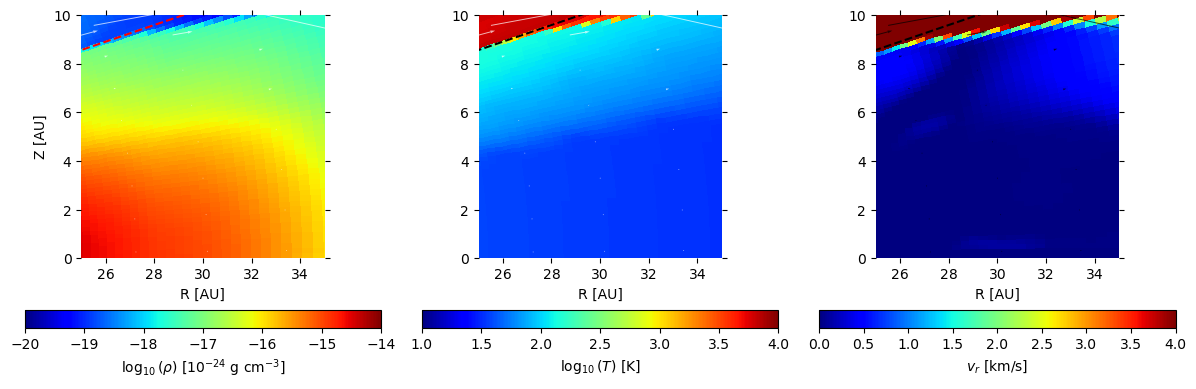

In [ ]:
fig , ax  = plt.subplots(1,3,sharey=False,sharex=False,figsize=(12,4))
fig.subplots_adjust(left=.15, bottom=.16, right=.99, top=.97)

# Prepare velocity components for quiver plot
X_AU = (grid["X"]*u.cm).to(u.AU).value
Z_AU = (grid["Z"]*u.cm).to(u.AU).value
vx_kms = (data["v_x"]*u.cm/u.s).to(u.km/u.s).value
vz_kms = (data["v_z"]*u.cm/u.s).to(u.km/u.s).value

# Downsample for cleaner vector display (zoom view needs fewer vectors)
skip = 8  # Plot every 8th vector for zoomed view

for i in range(3):
    ax[i].set_xlim(25, 35)
    ax[i].set_ylim(0, 10)
    ax[i].set_aspect('equal')
    ax[i].set_xlabel('R [AU]')
    ax[i].set_ylabel('Z [AU]')
    if (i==0):
        valmin = -20
        valmax = -14
        quantity = data["density"]
        #quantity = (np.where(Cd<5.e20,quantity,np.nan))
        labelplot = '$\\log_{10}(\\rho$) [$10^{-24}$ g cm$^{-3}$]'
        plot = ax[i].pcolormesh((grid["X"]*u.cm).to(u.AU).value, (grid["Z"]*u.cm).to(u.AU).value, np.log10(quantity),
                                vmin=valmin, vmax=valmax, cmap=plt.cm.jet)
        vals = [5.e20, 5.e21]
        #plt.Circle((0, 0), (grid['r'][0,fin]*u.cm).to(u.au), ax=ax[i], color='k', fill=False)
        circle = plt.Circle((0, 0), ((grid['r'][0,fin]*u.cm).to(u.au)).value, color='k', ls='dashed', fill=False)
        ax[i].add_patch(circle)
        contours1 = ax[i].contour((grid["X"]*u.cm).to(u.AU).value ,(grid["Z"]*u.cm).to(u.AU).value,
                                  data["column_density"], vals, 
                                  linestyles = 'dashed', colors='red')
        # Add velocity vectors
        Q = ax[i].quiver(X_AU[::skip, ::skip], Z_AU[::skip, ::skip], 
                     vx_kms[::skip, ::skip], vz_kms[::skip, ::skip],
                     color='white', alpha=0.7, scale=30, width=0.004)
        # Add velocity scale legend
        ax[i].quiverkey(Q, 0.85, 0.92, 5, '5 km/s', labelpos='E', 
                       coordinates='axes', color='white', labelcolor='white')

    if (i==1):
        valmin = 1
        valmax = 4
        quantity = data["temperature_gas"]
        #quantity = (np.where(Cd<5.e20,quantity,np.nan))
        labelplot = '$\\log_{10}(T)$ [K]'
        ax[i].set_ylabel("")
        plot = ax[i].pcolormesh((grid["X"]*u.cm).to(u.AU).value, (grid["Z"]*u.cm).to(u.AU).value, 
                                np.log10(quantity),
                                vmin=valmin,vmax=valmax,cmap=plt.cm.jet)
        vals = [5.e20, 5.e21]
        contours1 = ax[i].contour((grid["X"]*u.cm).to(u.AU).value, (grid["Z"]*u.cm).to(u.AU).value,
                                data["column_density"], vals, 
                                linestyles = 'dashed', colors='black')
        # Add velocity vectors
        Q = ax[i].quiver(X_AU[::skip, ::skip], Z_AU[::skip, ::skip], 
                     vx_kms[::skip, ::skip], vz_kms[::skip, ::skip],
                     color='white', alpha=0.7, scale=30, width=0.004)
        # Add velocity scale legend
        ax[i].quiverkey(Q, 0.85, 0.92, 5, '5 km/s', labelpos='E', 
                       coordinates='axes', color='white', labelcolor='white')

    if (i==2):
        valmin = 0
        valmax = 4
        quantity = (data["v_r"]*u.cm/u.s).to(u.km/u.s).value
        #quantity = np.log10(data["column_density"])
        #quantity = (np.where(Cd<5.e20,quantity,np.nan))
        labelplot = '$v_r$ [km/s]'
        ax[i].set_ylabel("")
        plot = ax[i].pcolormesh((grid["X"]*u.cm).to(u.AU).value, (grid["Z"]*u.cm).to(u.AU).value, 
                                quantity, vmin=valmin, vmax=valmax, cmap=plt.cm.jet)
        vals = [5.e20, 5.e21]
        contours1 = ax[i].contour((grid["X"]*u.cm).to(u.AU).value, (grid["Z"]*u.cm).to(u.AU).value,
                                  data["column_density"], vals, linestyles = 'dashed', colors='black')
        # Add velocity vectors
        Q = ax[i].quiver(X_AU[::skip, ::skip], Z_AU[::skip, ::skip], 
                     vx_kms[::skip, ::skip], vz_kms[::skip, ::skip],
                     color='black', alpha=0.7, scale=30, width=0.004)
        # Add velocity scale legend
        ax[i].quiverkey(Q, 0.85, 0.92, 5, '5 km/s', labelpos='E', 
                       coordinates='axes', color='black')

    fig.colorbar(plot, ax=ax[i], orientation='horizontal', label=labelplot)
    ax[i].tick_params(top='off', bottom='off', left='on', right='off', labelleft='on', labelbottom='on')
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    ax[i].spines["left"].set_visible(False)
    ax[i].spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()
plt.close(fig)

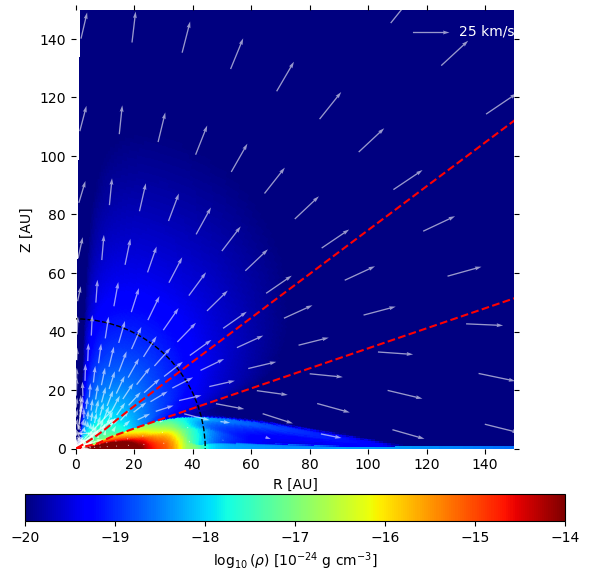

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
fig.subplots_adjust(left=.15, bottom=.12, right=.95, top=.95)

# Prepare velocity components for quiver plot
X_AU = (grid["X"]*u.cm).to(u.AU).value
Z_AU = (grid["Z"]*u.cm).to(u.AU).value
vx_kms = (data["v_x"]*u.cm/u.s).to(u.km/u.s).value
vz_kms = (data["v_z"]*u.cm/u.s).to(u.km/u.s).value

# Downsample for cleaner vector display
skip = 20  # Plot every 15th vector

ax.set_xlim(0, 150)
ax.set_ylim(0, 150)
ax.set_aspect('equal')
ax.set_xlabel('R [AU]')
ax.set_ylabel('Z [AU]')

# Plot density
valmin = -20
valmax = -14
quantity = data["density"]
labelplot = '$\\log_{10}(\\rho)$ [$10^{-24}$ g cm$^{-3}$]'
plot = ax.pcolormesh(X_AU, Z_AU, np.log10(quantity),
                     vmin=valmin, vmax=valmax, cmap=plt.cm.jet)

# Add contours
vals = [5.e20, 5.e21]
circle = plt.Circle((0, 0), ((grid['r'][0,fin]*u.cm).to(u.au)).value, 
                    color='k', ls='dashed', fill=False)
ax.add_patch(circle)
contours1 = ax.contour(X_AU, Z_AU, data["column_density"], vals, 
                       linestyles='dashed', colors='red')

# Add velocity vectors
Q = ax.quiver(X_AU[::skip, ::skip], Z_AU[::skip, ::skip], 
              vx_kms[::skip, ::skip], vz_kms[::skip, ::skip],
              color='white', alpha=0.6, scale=300, width=0.003)

# Add velocity scale legend
ax.quiverkey(Q, 0.85, 0.95, 25, '25 km/s', labelpos='E', 
             coordinates='axes', color='white', labelcolor='white')

# Colorbar
fig.colorbar(plot, ax=ax, orientation='horizontal', label=labelplot, pad=0.08)

# Clean up spines
ax.tick_params(top='off', bottom='off', left='on', right='off', 
               labelleft='on', labelbottom='on')
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()
plt.close(fig)

Using scienceplots style for publication quality
loading TeX Gyre fonts from "/usr/local/texlive/2022/texmf-dist/fonts/opentype/public/tex-gyre"
Processing 10au: 1 files
Processing 50au: 1 files
Processing 100au: 1 files
Processing 200au: 1 files


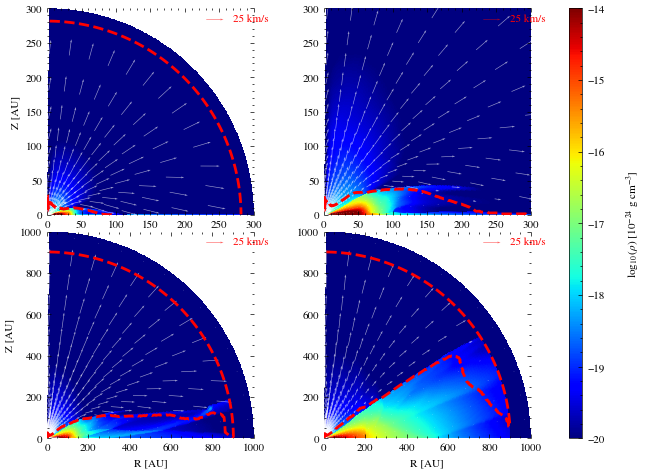

In [9]:

# ============================================================================
# PLOTTING CONFIGURATION
# ============================================================================
# Configure matplotlib for publication quality
import seaborn as sns
import subprocess
import matplotlib.font_manager as font_manager
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from astropy import constants as const
from astropy import units as u
from functions import read_data, read_grid, remove_disc, calc_streamline, regrid, calculate_mdot_wind, save_dict

plt.rcParams['text.usetex'] = False  # Disable LaTeX to avoid rendering issues

# Try to use science plots style if available
try:
    import scienceplots
    plt.style.use('science')
    print("Using scienceplots style for publication quality")
except ImportError:
    print("scienceplots not available, using default matplotlib style")

sns.set_palette("pastel")  # Set seaborn color palette

kpse_cp = subprocess.run(['kpsewhich', '-var-value', 'TEXMFDIST'], capture_output=True, check=True)
font_loc1 = os.path.join(kpse_cp.stdout.decode('utf8').strip(), 'fonts', 'opentype', 'public', 'tex-gyre')
print(f'loading TeX Gyre fonts from "{font_loc1}"')
font_dirs = [font_loc1]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

plt.rcParams['font.family'] = 'TeX Gyre Termes'
plt.rcParams["mathtext.fontset"] = "stix"

# MNRAS style configuration
# Column width: 240pt = 10/3 inches for single column
SMALL_SIZE = 8
MEDIUM_SIZE = 8
BIGGER_SIZE = 8

plt.rcParams['text.usetex'] = False  # Disable LaTeX to avoid rendering issues

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# Try to use Nimbus Roman font (MNRAS standard)
# try:
#     plt.rc('font', family='Nimbus Roman')
#    print("Using Nimbus Roman font (MNRAS standard)")
# except:
#    plt.rc('font', family='serif')
#    print("Nimbus Roman not available, using default serif font")

plt.rcParams["errorbar.capsize"] = 2

# Override specific parameters for MNRAS single-column figure
plt.rcParams.update({
    'figure.figsize': [20/3, 5.],  # MNRAS single column width
    'savefig.dpi': 400,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05
})

# Create 2x2 figure for different Rcrit directories with shared axes
# fig, axes = plt.subplots(2, 2, figsize=(12, 11), sharex=False, sharey=False)
fig, axes = plt.subplots(2, 2, figsize=(20/3, 5.), sharex=False, sharey=False)
fig.subplots_adjust(left=.08, bottom=.08, right=.88, top=.94, hspace=0.08, wspace=0.08)

# Define directories and labels
base_path = '/Users/giovanni/Papers/disc-photoevaporation-disk-radii/src/data/PLUTO_runs/'
directories = ['10au', '50au', '100au', '200au']
labels = ['R$_{crit}$ = 10 AU', 'R$_{crit}$ = 50 AU', 'R$_{crit}$ = 100 AU', 'R$_{crit}$ = 200 AU']
xlims = [300, 300, 1000, 1000]
rcrits = [10, 50, 100, 200]  # Cut-off radii for each directory

# Stellar mass (assuming 1 Msun)
Mstar = 1.0 * const.M_sun

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Store plot object for shared colorbar
plot_obj = None

for idx, (directory, label, xl, rcrit) in enumerate(zip(directories, labels, xlims, rcrits)):
    ax = axes_flat[idx]
    
    # Change to directory and read outputs
    output_dir = os.path.join(base_path, directory, 'out')
    os.chdir(output_dir)
    
    # Get list of data files and select last 10
    import glob
    data_files = sorted(glob.glob('data.*.dbl.h5'))
    last_10_files = data_files[-1:]
    
    print(f"Processing {directory}: {len(last_10_files)} files")
    
    # Initialize arrays for averaging
    density_avg = None
    vx_avg = None
    vz_avg = None
    column_density_avg = None
    
    # Read and average the last 10 outputs
    for file in last_10_files:
        grid_temp = read_grid(file)
        data_temp = read_data(file, grid_temp)
        
        if density_avg is None:
            density_avg = data_temp["density"]
            vx_avg = data_temp["v_x"]
            vz_avg = data_temp["v_z"]
            column_density_avg = data_temp["column_density"]
        else:
            density_avg += data_temp["density"]
            vx_avg += data_temp["v_x"]
            vz_avg += data_temp["v_z"]
            column_density_avg += data_temp["column_density"]
    
    # Calculate averages
    n_files = len(last_10_files)
    density_avg /= n_files
    vx_avg /= n_files
    vz_avg /= n_files
    column_density_avg /= n_files
    
    # Convert to appropriate units
    X_AU = (grid_temp["X"]*u.cm).to(u.AU).value
    Z_AU = (grid_temp["Z"]*u.cm).to(u.AU).value
    vx_kms = (vx_avg*u.cm/u.s).to(u.km/u.s).value
    vz_kms = (vz_avg*u.cm/u.s).to(u.km/u.s).value
    
    # Calculate gravitationally unbound region
    # Total velocity magnitude
    v_total = np.sqrt(vx_avg**2 + vz_avg**2)  # in cm/s
    
    # Distance from star (r = sqrt(x^2 + z^2))
    R_grid = grid_temp["X"]  # in cm
    Z_grid = grid_temp["Z"]  # in cm
    r_distance = np.sqrt(R_grid**2 + Z_grid**2)  # in cm
    
    # Escape velocity: v_esc = sqrt(2*G*M/r)
    v_escape = np.sqrt(2 * const.G.cgs.value * Mstar.cgs.value / r_distance)
    
    # Unbound region: where v_total > v_escape
    unbound_mask = v_total > v_escape
    
    # Find contour of unbound region
    unbound_contour_value = 1.0
    
    # Downsample for cleaner vector display
    skip = 20
    
    # Set plot properties
    ax.set_xlim(0, xl)
    ax.set_ylim(0, xl)
    ax.set_aspect('equal')
    
    # Add labels only to left and bottom subplots
    if idx in [0, 2]:  # Left column
        ax.set_ylabel('Z [AU]')
    if idx in [2, 3]:  # Bottom row
        ax.set_xlabel('R [AU]')
    
    # Remove y-axis ticks and labels for right column
    if idx in [1, 3]:  # Right column
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)
    
    # Add title to each subplot
    # ax.set_title(label, fontsize=14, fontweight='bold', pad=10)
    
    # Plot density
    valmin = -20
    valmax = -14
    labelplot = '$\\log_{10}(\\rho)$ [$10^{-24}$ g cm$^{-3}$]'
    plot = ax.pcolormesh(X_AU, Z_AU, np.log10(density_avg),
                         vmin=valmin, vmax=valmax, cmap=plt.cm.jet)
    
    # Store plot object for colorbar (use last one)
    plot_obj = plot
    
    # Add contours for column density
    # vals = [5.e20, 5.e21]
    DIMR = grid_temp['X'].shape[1]
    fin = DIMR - 150
    #circle = plt.Circle((0, 0), ((grid_temp['r'][0,fin]*u.cm).to(u.au)).value, 
    #                    color='k', ls='dashed', fill=False, linewidth=1.5)
    #ax.add_patch(circle)
    # contours1 = ax.contour(X_AU, Z_AU, column_density_avg, vals, 
    #                        linestyles='dashed', colors='red', linewidths=1.5)
    
    # Add contour for gravitationally unbound region
    unbound_contour = ax.contour(X_AU, Z_AU, unbound_mask.astype(float), 
                                 levels=[0.5], linestyles='dashed', 
                                 colors='red', linewidths=2.0)
    
    # Add velocity vectors
    Q = ax.quiver(X_AU[::skip, ::skip], Z_AU[::skip, ::skip], 
                  vx_kms[::skip, ::skip], vz_kms[::skip, ::skip],
                  color='white', alpha=0.6, scale=300, width=0.003)
    
    # Add velocity scale legend
    ax.quiverkey(Q, 0.85, 0.95, 25, '25 km/s', labelpos='E', 
                 coordinates='axes', color='red', labelcolor='red')
    # Clean up spines
    ax.tick_params(top='off', bottom='on', left='on', right='off', 
                   labelleft='on', labelbottom='on')
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

# Add single colorbar on the right side
cbar_ax = fig.add_axes([0.90, 0.08, 0.02, 0.86])  # [left, bottom, width, height]
cbar = fig.colorbar(plot_obj, cax=cbar_ax, orientation='vertical')
cbar.set_label(labelplot, labelpad=15)

#plt.suptitle('Density and Velocity Fields', 
#             fontsize=16, fontweight='bold', y=0.97)
plt.savefig('comparison_Rcrit_density_velocity.png', dpi=400)
plt.show()
plt.close(fig)


In [5]:
# ============================================================================
# CALCULATE E-FOLDING RADIUS FOR SURFACE DENSITY
# ============================================================================
# Process the same files as Cell 8 to calculate the e-folding radius
# of the vertically integrated surface density for each run

import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from astropy import constants as const
from scipy.optimize import curve_fit
import os
import glob

# Define directories and labels (same as Cell 8)
base_path = '/Users/giovanni/Papers/disc-photoevaporation-disk-radii/src/data/PLUTO_runs/'
directories = ['10au', '50au', '100au', '200au']
labels = ['R$_{crit}$ = 10 AU', 'R$_{crit}$ = 50 AU', 'R$_{crit}$ = 100 AU', 'R$_{crit}$ = 200 AU']
rcrits = [10, 50, 100, 200]  # Cut-off radii for each directory

# Store results
e_folding_radii = []
surface_density_profiles = []
radial_coordinates = []

# Exponential function for fitting: Σ(R) = Σ_0 * exp(-R/r_e)
def exponential_decay(r, sigma_0, r_e):
    """
    Exponential decay function for surface density profile
    r: radial distance in AU
    sigma_0: surface density at r=0
    r_e: e-folding radius (scale length)
    """
    return sigma_0 * np.exp(-r / r_e)

print("="*80)
print("CALCULATING E-FOLDING RADIUS FOR SURFACE DENSITY")
print("="*80)

for idx, (directory, label, rcrit) in enumerate(zip(directories, labels, rcrits)):
    print(f"\nProcessing {directory} (Rcrit = {rcrit} AU)")
    print("-" * 60)
    
    # Change to directory and read last output file
    output_dir = os.path.join(base_path, directory, 'out')
    os.chdir(output_dir)
    
    # Get list of data files and select last one (same as Cell 8)
    data_files = sorted(glob.glob('data.*.dbl.h5'))
    last_file = data_files[-1]
    
    print(f"  Reading: {last_file}")
    
    # Read grid and data
    grid_temp = read_grid(last_file)
    data_temp = read_data(last_file, grid_temp)
    
    # Regrid from spherical (r,θ) to Cartesian (X,Z) grid manually
    # This is essentially what regrid() does but we'll keep the arrays
    print(f"  Regridding to Cartesian grid...")
    
    from scipy.spatial import cKDTree
    
    res = 500  # Grid resolution
    r_max_cm = grid_temp['r'].value.max() if hasattr(grid_temp['r'], 'value') else grid_temp['r'].max()
    xcart_cm = np.logspace(np.log10(1e12), np.log10(r_max_cm * 0.99999), res)
    zcart_cm = np.copy(xcart_cm)
    Xc, Zc = np.meshgrid(xcart_cm, zcart_cm)
    
    # Prepare source points (original spherical grid projected to Cartesian)
    X_flat = grid_temp['X'].value.ravel() if hasattr(grid_temp['X'], 'value') else grid_temp['X'].ravel()
    Z_flat = grid_temp['Z'].value.ravel() if hasattr(grid_temp['Z'], 'value') else grid_temp['Z'].ravel()
    source_points = np.column_stack((X_flat, Z_flat))
    target_points = np.column_stack((Xc.ravel(), Zc.ravel()))
    
    # Build KD-tree for nearest neighbor interpolation
    tree = cKDTree(source_points)
    _, indices = tree.query(target_points)
    
    # Extract density values (handle astropy units)
    density_flat = data_temp["density"].value.ravel() if hasattr(data_temp["density"], 'value') else data_temp["density"].ravel()
    
    # Map to new grid
    density_regrid = density_flat[indices].reshape(res, res)
    
    # Convert grid to AU
    xcart_AU = (xcart_cm * u.cm).to(u.AU).value
    zcart_AU = (zcart_cm * u.cm).to(u.AU).value
    
    # Calculate surface density by integrating along Z at each R
    # density_regrid has shape (nz, nx) where axis 0 is Z, axis 1 is R
    surface_density = np.zeros(len(xcart_AU))
    
    for i_r in range(len(xcart_AU)):
        # Extract density column at this radius (all Z values at fixed R)
        rho_column = density_regrid[:, i_r]
        z_column = zcart_cm
        
        # Filter out negative values (markers for disk) and very small values
        valid_mask = rho_column > 1e-30  # Use small positive threshold
        
        if np.sum(valid_mask) > 1:
            rho_valid = rho_column[valid_mask]
            z_valid = z_column[valid_mask]
            
            # Integrate: Σ = 2 * ∫ ρ dz (factor of 2 for both sides of midplane)
            surface_density[i_r] = 2.0 * np.trapz(rho_valid, z_valid)
        else:
            surface_density[i_r] = 0.0
    
    # Use the radial coordinate
    R_AU = xcart_AU
    
    # Store for plotting
    surface_density_profiles.append(surface_density)
    radial_coordinates.append(R_AU)
    
    print(f"  Surface density range: {surface_density.min():.2e} to {surface_density.max():.2e} g/cm^2")
    print(f"  Number of positive values: {np.sum(surface_density > 0)}")
    
    # Select fitting range: more flexible range that adapts to the data
    # Look for the region where surface density is significant
    positive_mask = surface_density > 0
    if np.sum(positive_mask) < 10:
        print(f"  ✗ Not enough positive surface density values")
        e_folding_radii.append(np.nan)
        continue
    
    # Find the peak and fit around it
    R_positive = R_AU[positive_mask]
    Sigma_positive = surface_density[positive_mask]
    peak_idx = np.argmax(Sigma_positive)
    R_peak = R_positive[peak_idx]
    
    # Fit from the peak outward to ~3*Rcrit or where density drops significantly
    r_inner = R_peak  # Start from peak
    r_outer = min(R_peak + 3*rcrit, R_AU.max() * 0.9)  # Extend to 3*Rcrit from peak
    
    fit_mask = (R_AU >= r_inner) & (R_AU <= r_outer) & (surface_density > 0)
    
    # Filter out very low density regions (below 5% of peak)
    density_threshold = Sigma_positive.max() * 0.05
    fit_mask = fit_mask & (surface_density > density_threshold)
    
    R_fit = R_AU[fit_mask]
    Sigma_fit = surface_density[fit_mask]
    
    # Check if we have enough points for fitting
    if len(R_fit) < 5:
        print(f"  ✗ Not enough valid points for fitting ({len(R_fit)} points)")
        e_folding_radii.append(np.nan)
        continue
    
    print(f"  Fitting range: {R_fit.min():.1f} to {R_fit.max():.1f} AU ({len(R_fit)} points)")
    print(f"  Peak surface density at R = {R_peak:.1f} AU")
    
    # Fit exponential decay
    try:
        # Initial guess: use the peak value and rcrit as scale
        sigma_0_guess = Sigma_positive.max()
        r_e_guess = rcrit if rcrit > 10 else 20  # Use at least 20 AU for small Rcrit
        p0 = [sigma_0_guess, r_e_guess]
        
        # Perform curve fitting with bounds to ensure physical values
        bounds = ([0, 1], [np.inf, R_fit.max()])  # Sigma_0 > 0, r_e between 1 and max(R)
        popt, pcov = curve_fit(exponential_decay, R_fit, Sigma_fit, p0=p0, 
                              bounds=bounds, maxfev=10000)
        
        sigma_0_fit, r_e_fit = popt
        
        # Calculate uncertainty
        perr = np.sqrt(np.diag(pcov))
        r_e_err = perr[1]
        
        e_folding_radii.append(r_e_fit)
        
        print(f"  ✓ Fit successful!")
        print(f"    Σ_0 = {sigma_0_fit:.2e} g/cm^2")
        print(f"    r_e = {r_e_fit:.2f} ± {r_e_err:.2f} AU")
        
    except Exception as e:
        print(f"  ✗ Fitting failed: {e}")
        e_folding_radii.append(np.nan)

print("\n" + "="*80)
print("SUMMARY OF E-FOLDING RADII")
print("="*80)
for idx, (directory, rcrit, r_e) in enumerate(zip(directories, rcrits, e_folding_radii)):
    print(f"{directory:25s}  Rcrit = {rcrit:3d} AU  →  r_e = {r_e:.2f} AU")
print("="*80)

CALCULATING E-FOLDING RADIUS FOR SURFACE DENSITY

Processing 10au (Rcrit = 10 AU)
------------------------------------------------------------
  Reading: data.0266.dbl.h5
  Regridding to Cartesian grid...


/var/folders/zc/y003zj4j3r9234xrflkf78040000gn/T/ipykernel_4215/1485963142.py:107: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  surface_density[i_r] = 2.0 * np.trapz(rho_valid, z_valid)


  Surface density range: 5.30e-07 to 1.17e+01 g/cm^2
  Number of positive values: 500
  Fitting range: 8.1 to 21.9 AU (60 points)
  Peak surface density at R = 8.1 AU
  ✓ Fit successful!
    Σ_0 = 5.12e+01 g/cm^2
    r_e = 6.16 ± 0.25 AU

Processing 50au (Rcrit = 50 AU)
------------------------------------------------------------
  Reading: data.0315.dbl.h5
  Regridding to Cartesian grid...
  Surface density range: 8.85e-07 to 1.37e+01 g/cm^2
  Number of positive values: 500
  Fitting range: 10.9 to 54.4 AU (91 points)
  Peak surface density at R = 10.9 AU
  ✓ Fit successful!
    Σ_0 = 2.30e+01 g/cm^2
    r_e = 21.74 ± 0.52 AU

Processing 100au (Rcrit = 100 AU)
------------------------------------------------------------
  Reading: data.0338.dbl.h5
  Regridding to Cartesian grid...
  Surface density range: 1.77e-06 to 1.35e+01 g/cm^2
  Number of positive values: 500
  Fitting range: 11.0 to 104.7 AU (118 points)
  Peak surface density at R = 11.0 AU
  ✓ Fit successful!
    Σ_0 = 1.97e+

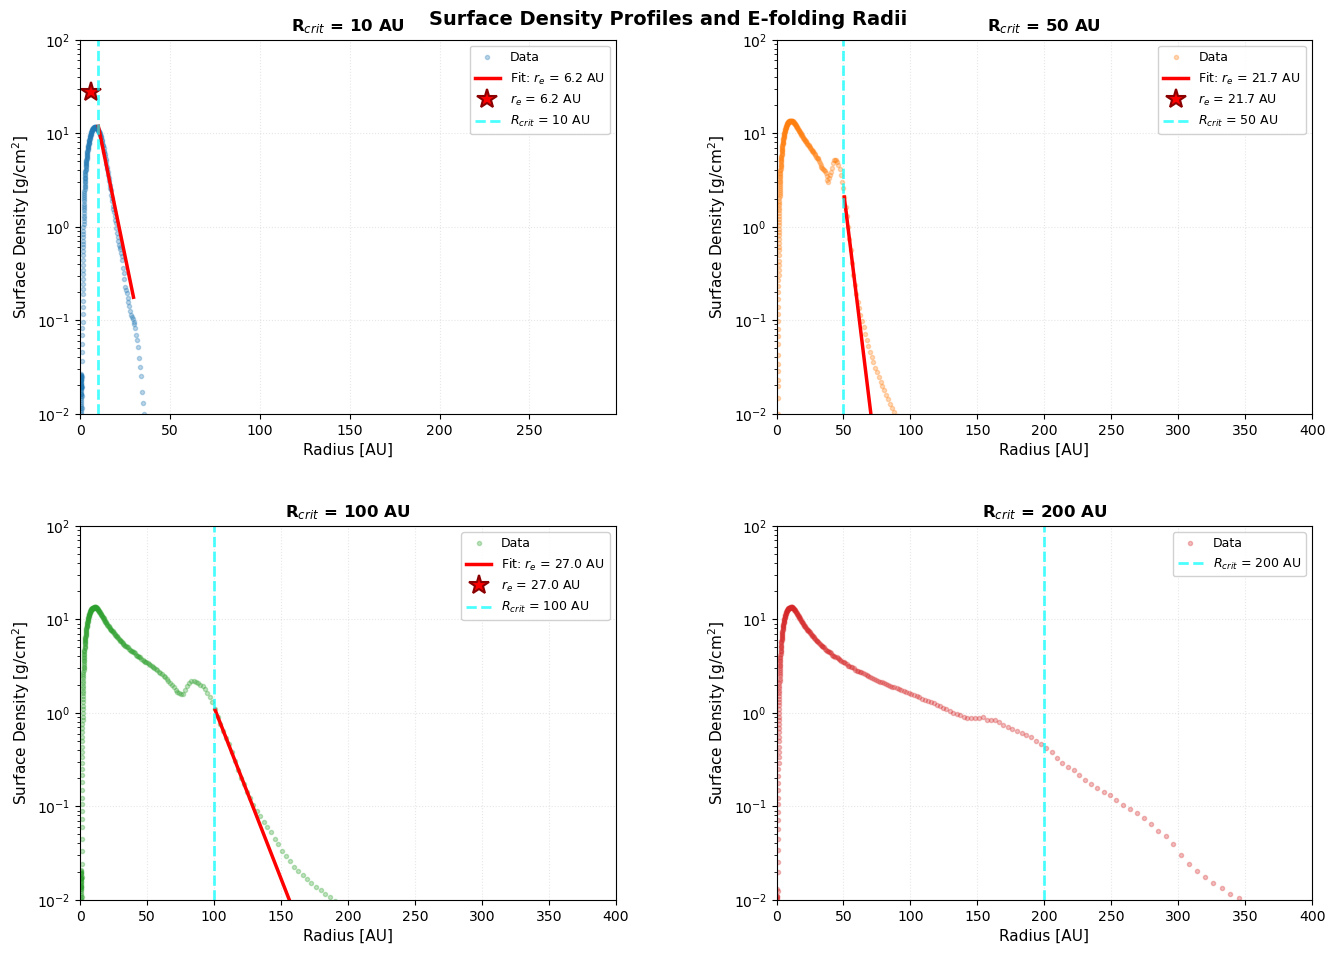

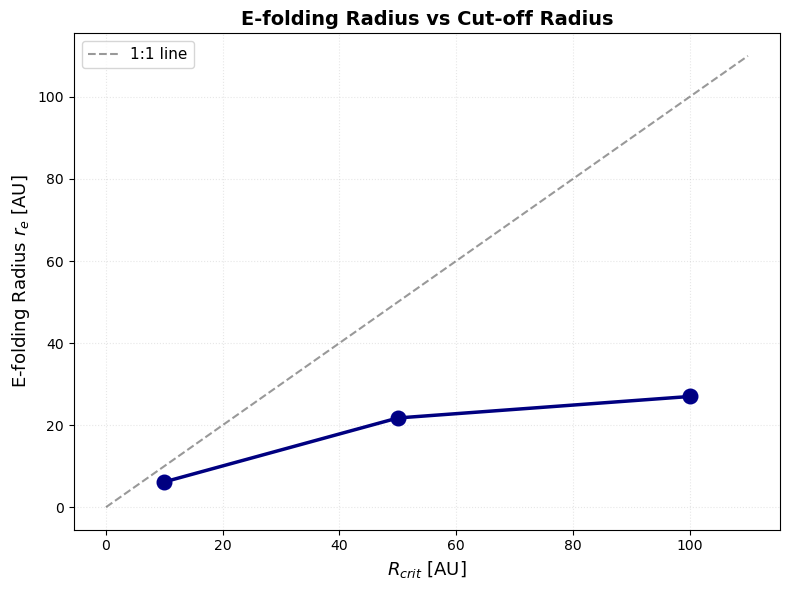

In [6]:
# ============================================================================
# VISUALIZE SURFACE DENSITY PROFILES AND E-FOLDING RADII
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.subplots_adjust(left=.08, bottom=.08, right=.96, top=.94, hspace=0.3, wspace=0.3)
axes_flat = axes.flatten()

# Color scheme
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, (directory, label, rcrit, r_e, R_AU, Sigma) in enumerate(
    zip(directories, labels, rcrits, e_folding_radii, radial_coordinates, surface_density_profiles)):
    
    ax = axes_flat[idx]
    
    # Plot surface density profile
    ax.semilogy(R_AU, Sigma, 'o', color=colors[idx], alpha=0.3, 
                markersize=3, label='Data')
    
    # Plot exponential fit if successful
    if not np.isnan(r_e):
        # Reconstruct fit over full range
        fit_mask = (R_AU > rcrit) & (R_AU < 3*rcrit)
        density_threshold = Sigma.max() * 1e-3
        fit_mask = fit_mask & (Sigma > density_threshold)
        
        R_fit = R_AU[fit_mask]
        Sigma_fit = Sigma[fit_mask]
        
        # Refit to get sigma_0
        p0 = [Sigma.max(), rcrit]
        popt, _ = curve_fit(exponential_decay, R_fit, Sigma_fit, p0=p0, maxfev=10000)
        sigma_0_fit, r_e_fit = popt
        
        # Generate smooth fit curve
        R_smooth = np.linspace(R_fit.min(), R_fit.max(), 200)
        Sigma_fit_smooth = exponential_decay(R_smooth, sigma_0_fit, r_e_fit)
        
        ax.semilogy(R_smooth, Sigma_fit_smooth, '-', color='red', linewidth=2.5,
                   label=f'Fit: $r_e$ = {r_e:.1f} AU')
        
        # Mark the e-folding radius
        Sigma_at_re = exponential_decay(r_e, sigma_0_fit, r_e_fit)
        ax.plot(r_e, Sigma_at_re, 'r*', markersize=15, 
               markeredgecolor='darkred', markeredgewidth=1.5,
               label=f'$r_e$ = {r_e:.1f} AU')
    
    # Mark Rcrit
    if rcrit < R_AU.max():
        ax.axvline(rcrit, color='cyan', linestyle='--', linewidth=2, 
                  alpha=0.7, label=f'$R_{{crit}}$ = {rcrit} AU')
    
    # Formatting
    ax.set_xlabel('Radius [AU]', fontsize=11)
    ax.set_ylabel('Surface Density [g/cm$^2$]', fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
    ax.legend(loc='best', fontsize=9, framealpha=0.9)
    
    # Set reasonable limits
    ax.set_xlim(0, min(R_AU.max(), 400))
    ax.set_ylim(1.e-2, 1e2)

plt.suptitle('Surface Density Profiles and E-folding Radii', 
             fontsize=14, fontweight='bold', y=0.97)

plt.savefig('surface_density_efolding_radii.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

# Create comparison plot of e-folding radius vs Rcrit
fig2, ax2 = plt.subplots(1, 1, figsize=(8, 6))

valid_mask = ~np.isnan(e_folding_radii)
rcrits_valid = np.array(rcrits)[valid_mask]
r_e_valid = np.array(e_folding_radii)[valid_mask]

ax2.plot(rcrits_valid, r_e_valid, 'o-', color='navy', markersize=10, 
         linewidth=2.5, markeredgecolor='darkblue', markeredgewidth=1.5)

# Add 1:1 line for reference
r_range = [0, max(rcrits_valid.max(), r_e_valid.max()) * 1.1]
ax2.plot(r_range, r_range, 'k--', alpha=0.4, linewidth=1.5, label='1:1 line')

ax2.set_xlabel('$R_{crit}$ [AU]', fontsize=13)
ax2.set_ylabel('E-folding Radius $r_e$ [AU]', fontsize=13)
ax2.set_title('E-folding Radius vs Cut-off Radius', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax2.legend(loc='best', fontsize=11)

plt.tight_layout()
plt.savefig('efolding_vs_rcrit.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig2)

Processing 10au: 10 files
Processing 50au: 10 files
Processing 100au: 10 files
Processing 200au: 10 files


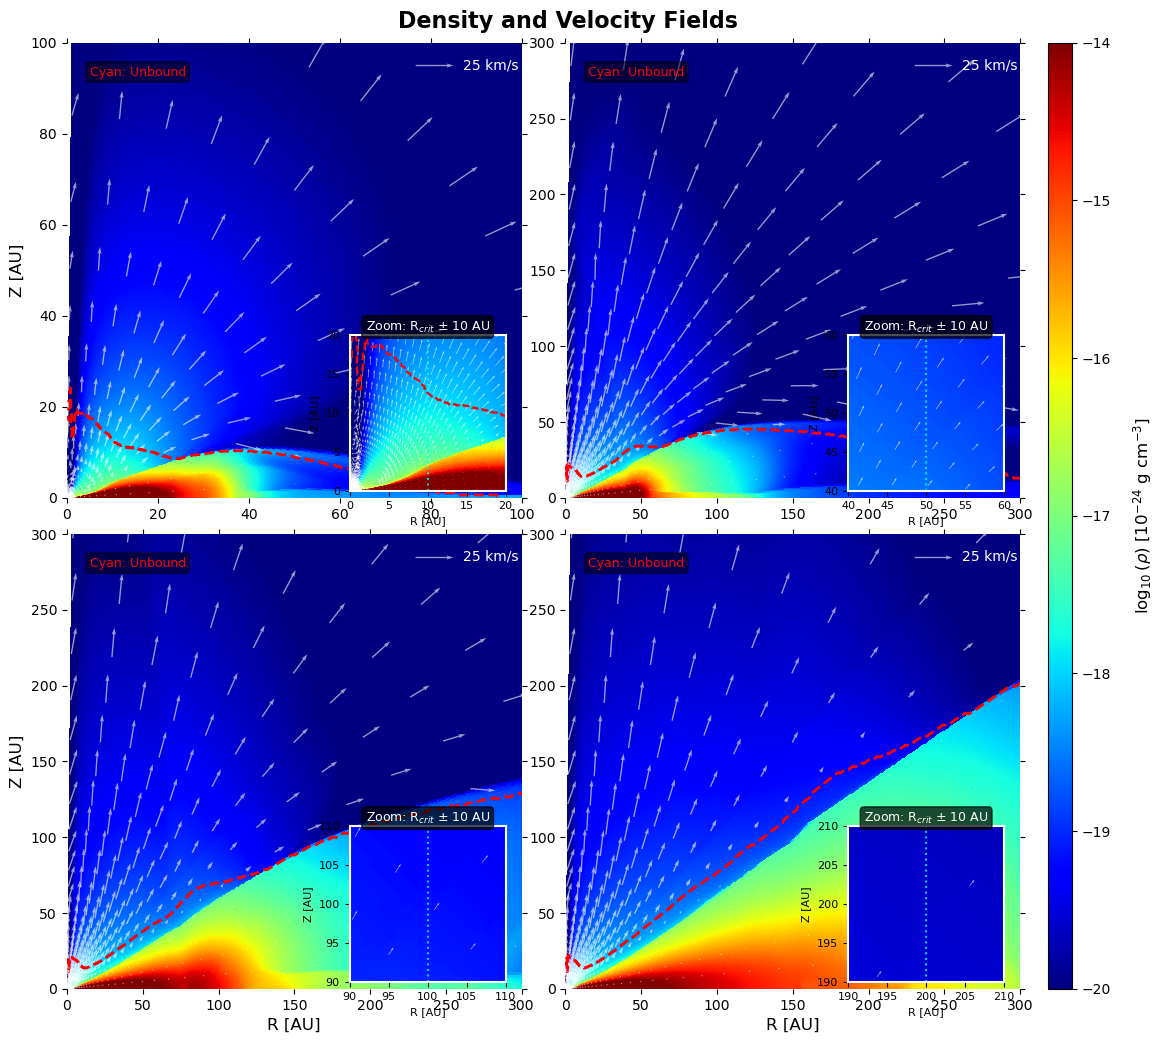

In [7]:
# Create 2x2 figure for different Rcrit directories with shared axes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axes = plt.subplots(2, 2, figsize=(12, 11), sharex=False, sharey=False)
fig.subplots_adjust(left=.08, bottom=.08, right=.88, top=.94, hspace=0.08, wspace=0.08)

# Define directories and labels
base_path = '/Users/giovanni/Papers/disc-photoevaporation-disk-radii/src/data/PLUTO_runs'
directories = ['10au', '50au', '100au', '200au']
labels = ['R$_{crit}$ = 10 AU', 'R$_{crit}$ = 50 AU', 'R$_{crit}$ = 100 AU', 'R$_{crit}$ = 200 AU']
xlims = [100, 300, 300, 300]
rcrits = [10, 50, 100, 200]  # Cut-off radii for each directory

# Stellar mass (assuming 1 Msun)
Mstar = 1.0 * const.M_sun

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Store plot object for shared colorbar
plot_obj = None

for idx, (directory, label, xl, rcrit) in enumerate(zip(directories, labels, xlims, rcrits)):
    ax = axes_flat[idx]
    
    # Change to directory and read outputs
    output_dir = os.path.join(base_path, directory, 'out')
    os.chdir(output_dir)
    
    # Get list of data files and select last 10
    import glob
    data_files = sorted(glob.glob('data.*.dbl.h5'))
    last_10_files = data_files[-10:]
    
    print(f"Processing {directory}: {len(last_10_files)} files")
    
    # Initialize arrays for averaging
    density_avg = None
    vx_avg = None
    vz_avg = None
    column_density_avg = None
    
    # Read and average the last 10 outputs
    for file in last_10_files:
        grid_temp = read_grid(file)
        data_temp = read_data(file, grid_temp)
        
        if density_avg is None:
            density_avg = data_temp["density"]
            vx_avg = data_temp["v_x"]
            vz_avg = data_temp["v_z"]
            column_density_avg = data_temp["column_density"]
        else:
            density_avg += data_temp["density"]
            vx_avg += data_temp["v_x"]
            vz_avg += data_temp["v_z"]
            column_density_avg += data_temp["column_density"]
    
    # Calculate averages
    n_files = len(last_10_files)
    density_avg /= n_files
    vx_avg /= n_files
    vz_avg /= n_files
    column_density_avg /= n_files
    
    # Convert to appropriate units
    X_AU = (grid_temp["X"]*u.cm).to(u.AU).value
    Z_AU = (grid_temp["Z"]*u.cm).to(u.AU).value
    vx_kms = (vx_avg*u.cm/u.s).to(u.km/u.s).value
    vz_kms = (vz_avg*u.cm/u.s).to(u.km/u.s).value
    
    # Calculate gravitationally unbound region
    # Total velocity magnitude
    v_total = np.sqrt(vx_avg**2 + vz_avg**2)  # in cm/s
    
    # Distance from star (r = sqrt(x^2 + z^2))
    R_grid = grid_temp["X"]  # in cm
    Z_grid = grid_temp["Z"]  # in cm
    r_distance = np.sqrt(R_grid**2 + Z_grid**2)  # in cm
    
    # Escape velocity: v_esc = sqrt(2*G*M/r)
    v_escape = np.sqrt(2 * const.G.cgs.value * Mstar.cgs.value / r_distance)
    
    # Unbound region: where v_total > v_escape
    unbound_mask = v_total > v_escape
    
    # Find contour of unbound region
    unbound_contour_value = 1.0
    
    # Downsample for cleaner vector display
    skip = 20
    
    # Set plot properties
    ax.set_xlim(0, xl)
    ax.set_ylim(0, xl)
    ax.set_aspect('equal')
    
    # Add labels only to left and bottom subplots
    if idx in [0, 2]:  # Left column
        ax.set_ylabel('Z [AU]', fontsize=12)
    if idx in [2, 3]:  # Bottom row
        ax.set_xlabel('R [AU]', fontsize=12)
    
    # Add title to each subplot
    # ax.set_title(label, fontsize=14, fontweight='bold', pad=10)
    
    # Plot density
    valmin = -20
    valmax = -14
    labelplot = '$\\log_{10}(\\rho)$ [$10^{-24}$ g cm$^{-3}$]'
    plot = ax.pcolormesh(X_AU, Z_AU, np.log10(density_avg),
                         vmin=valmin, vmax=valmax, cmap=plt.cm.jet)
    
    # Store plot object for colorbar (use last one)
    plot_obj = plot
    
    # Add contours for column density
    # vals = [5.e20, 5.e21]
    DIMR = grid_temp['X'].shape[1]
    fin = DIMR - 150
    #circle = plt.Circle((0, 0), ((grid_temp['r'][0,fin]*u.cm).to(u.au)).value, 
    #                    color='k', ls='dashed', fill=False, linewidth=1.5)
    #ax.add_patch(circle)
    # contours1 = ax.contour(X_AU, Z_AU, column_density_avg, vals, 
    #                        linestyles='dashed', colors='red', linewidths=1.5)
    
    # Add contour for gravitationally unbound region
    unbound_contour = ax.contour(X_AU, Z_AU, unbound_mask.astype(float), 
                                 levels=[0.5], linestyles='dashed', 
                                 colors='red', linewidths=2.0)
    
    # Add velocity vectors
    Q = ax.quiver(X_AU[::skip, ::skip], Z_AU[::skip, ::skip], 
                  vx_kms[::skip, ::skip], vz_kms[::skip, ::skip],
                  color='white', alpha=0.6, scale=300, width=0.003)
    
    # Add velocity scale legend
    ax.quiverkey(Q, 0.85, 0.95, 25, '25 km/s', labelpos='E', 
                 coordinates='axes', color='white', labelcolor='white',
                 fontproperties={'size': 10})
    
    # Add text label for unbound region
    ax.text(0.05, 0.95, 'Cyan: Unbound', transform=ax.transAxes,
            fontsize=9, verticalalignment='top', color='red',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
    
    # Add inset zoom around cut-off radius
    # Define zoom region: Rcrit ± 10 AU
    zoom_margin = 10  # AU
    r_min_zoom = max(0, rcrit - zoom_margin)
    r_max_zoom = rcrit + zoom_margin
    
    # Create inset axes
    axins = inset_axes(ax, width="35%", height="35%", loc='lower right',
                      bbox_to_anchor=(0, 0, 0.98, 0.98), bbox_transform=ax.transAxes)
    
    # Plot density in inset
    axins.pcolormesh(X_AU, Z_AU, np.log10(density_avg),
                    vmin=valmin, vmax=valmax, cmap=plt.cm.jet)
    
    # Add unbound contour in inset
    axins.contour(X_AU, Z_AU, unbound_mask.astype(float), 
                 levels=[0.5], linestyles='dashed', 
                 colors='red', linewidths=1.5)
    
    # Add velocity vectors in inset (higher resolution)
    skip_inset = 8
    axins.quiver(X_AU[::skip_inset, ::skip_inset], Z_AU[::skip_inset, ::skip_inset], 
                vx_kms[::skip_inset, ::skip_inset], vz_kms[::skip_inset, ::skip_inset],
                color='white', alpha=0.7, scale=150, width=0.004)
    
    # Set zoom limits
    axins.set_xlim(r_min_zoom, r_max_zoom)
    axins.set_ylim(r_min_zoom, r_max_zoom)
    axins.set_aspect('equal')
    
    # Add vertical line at Rcrit in inset
    axins.axvline(rcrit, color='cyan', linestyle=':', linewidth=1.5, alpha=0.8)
    
    # Style inset
    axins.tick_params(labelsize=8)
    axins.set_xlabel('R [AU]', fontsize=8)
    axins.set_ylabel('Z [AU]', fontsize=8)
    
    # Add title to inset
    axins.set_title(f'Zoom: R$_{{crit}}$ ± {zoom_margin} AU', fontsize=9, 
                   color='white', pad=3, 
                   bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
    
    # Make inset spines white for visibility
    for spine in axins.spines.values():
        spine.set_edgecolor('white')
        spine.set_linewidth(1.5)
    
    # Clean up spines
    ax.tick_params(top='off', bottom='on', left='on', right='off', 
                   labelleft='on', labelbottom='on')
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

# Add single colorbar on the right side
cbar_ax = fig.add_axes([0.90, 0.08, 0.02, 0.86])  # [left, bottom, width, height]
cbar = fig.colorbar(plot_obj, cax=cbar_ax, orientation='vertical')
cbar.set_label(labelplot, fontsize=12, labelpad=15)

plt.suptitle('Density and Velocity Fields', 
             fontsize=16, fontweight='bold', y=0.97)

plt.show()
plt.close(fig)


Creating video for 10au
Total files: 27
Creating animation...
Saving to 10au_evolution.mp4...


AttributeError: 'QuadContourSet' object has no attribute 'collections'

Error in callback <function _draw_all_if_interactive at 0x11f9b3ce0> (for post_execute), with arguments args (),kwargs {}:


AttributeError: 'QuadContourSet' object has no attribute 'collections'

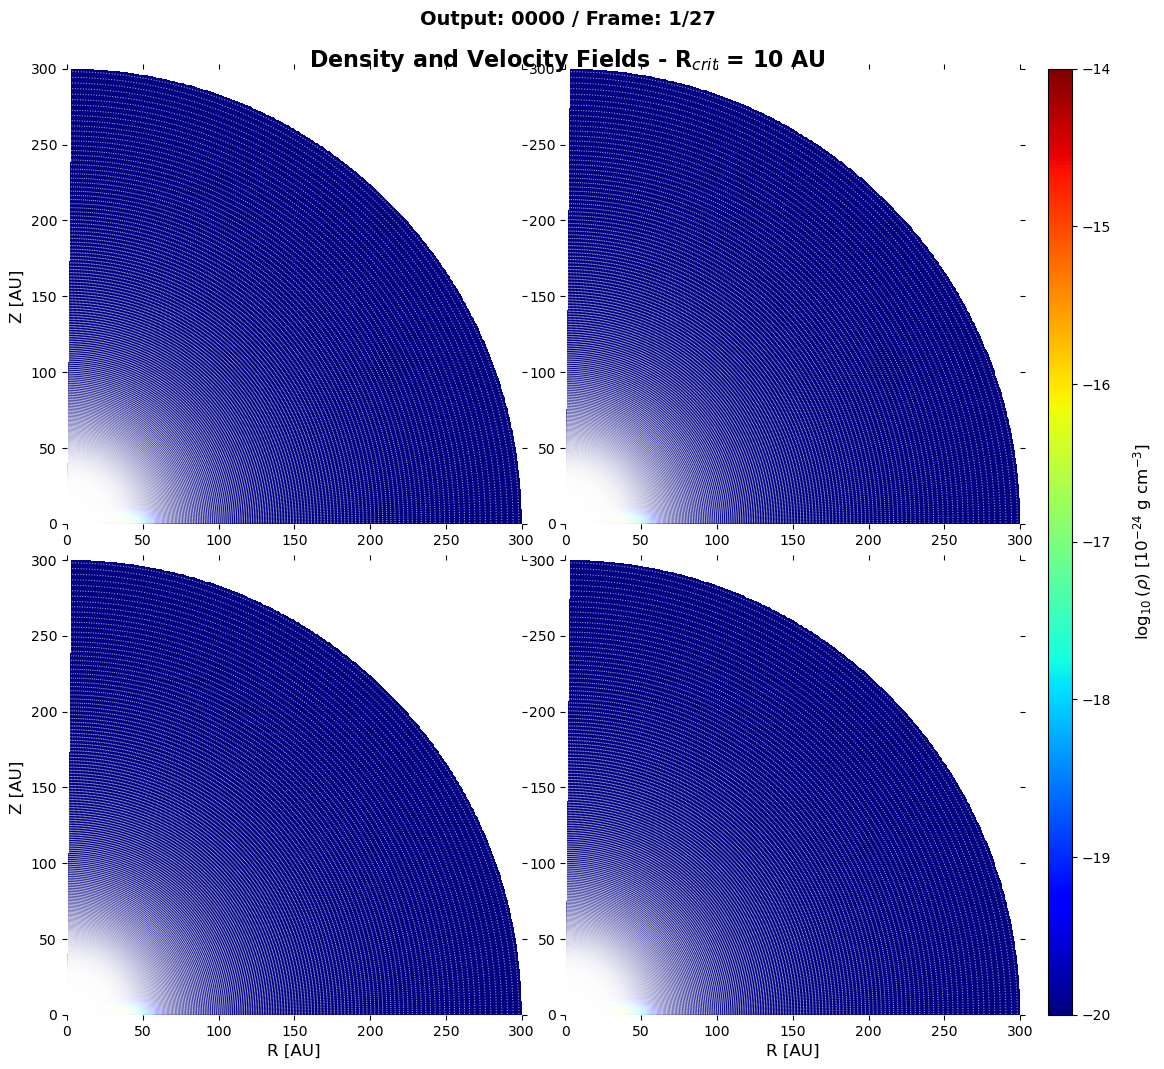

In [9]:
# Create MP4 video of evolution for each Rcrit directory
import matplotlib.animation as animation
from IPython.display import Video

# Define directories and labels
base_path = '/Users/giovanni/Papers/disc-photoevaporation-disk-radii/src/data/PLUTO_runs/'
directories = ['10au', '50au', '100au', '200au']
labels = ['R$_{crit}$ = 10 AU', 'R$_{crit}$ = 50 AU', 'R$_{crit}$ = 100 AU', 'R$_{crit}$ = 200 AU']
xlims = [300, 500, 1000, 1000]

# Stellar mass (assuming 1 Msun)
Mstar = 1.0 * const.M_sun

# Create video for each directory
for dir_idx, (directory, label, xl) in enumerate(zip(directories, labels, xlims)):
    print(f"\n{'='*60}")
    print(f"Creating video for {directory}")
    print(f"{'='*60}")
    
    # Change to directory and read outputs
    output_dir = os.path.join(base_path, directory, 'out')
    os.chdir(output_dir)
    
    # Get list of all data files
    import glob
    data_files = sorted(glob.glob('data.*.dbl.h5'))
    
    # Skip every N files to speed up video (e.g., every 10th file)
    skip_factor = 10
    data_files = data_files[::skip_factor]
    
    print(f"Total files: {len(data_files)}")
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(12, 11), sharex=False, sharey=False)
    fig.subplots_adjust(left=.08, bottom=.08, right=.88, top=.94, hspace=0.08, wspace=0.08)
    axes_flat = axes.flatten()
    
    # Initialize plot objects
    plots = []
    contours = []
    quivers = []
    time_text = fig.text(0.5, 0.98, '', ha='center', fontsize=14, fontweight='bold')
    
    # Set up each subplot
    for idx in range(4):
        ax = axes_flat[idx]
        ax.set_xlim(0, xl)
        ax.set_ylim(0, xl)
        ax.set_aspect('equal')
        
        if idx in [0, 2]:  # Left column
            ax.set_ylabel('Z [AU]', fontsize=12)
        if idx in [2, 3]:  # Bottom row
            ax.set_xlabel('R [AU]', fontsize=12)
        
        ax.tick_params(top='off', bottom='on', left='on', right='off', 
                       labelleft='on', labelbottom='on')
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
    
    # Read first file to initialize
    grid_temp = read_grid(data_files[0])
    data_temp = read_data(data_files[0], grid_temp)
    
    X_AU = (grid_temp["X"]*u.cm).to(u.AU).value
    Z_AU = (grid_temp["Z"]*u.cm).to(u.AU).value
    
    skip = 1
    valmin = -20
    valmax = -14
    labelplot = '$\\log_{10}(\\rho)$ [$10^{-24}$ g cm$^{-3}$]'
    
    # Initialize plots for each subplot
    for idx in range(4):
        ax = axes_flat[idx]
        plot = ax.pcolormesh(X_AU, Z_AU, np.log10(data_temp["density"]),
                           vmin=valmin, vmax=valmax, cmap=plt.cm.jet)
        plots.append(plot)
        contours.append(None)
        quivers.append(None)
    
    # Add colorbar
    cbar_ax = fig.add_axes([0.90, 0.08, 0.02, 0.86])
    cbar = fig.colorbar(plots[0], cax=cbar_ax, orientation='vertical')
    cbar.set_label(labelplot, fontsize=12, labelpad=15)
    
    plt.suptitle(f'Density and Velocity Fields - {label}', 
                 fontsize=16, fontweight='bold', y=0.96)
    
    # Animation update function
    def update(frame):
        file = data_files[frame]
        
        # Read data
        grid_temp = read_grid(file)
        data_temp = read_data(file, grid_temp)
        
        # Get time from filename (output number)
        output_num = int(file.split('.')[-3])
        
        # Convert to appropriate units
        X_AU = (grid_temp["X"]*u.cm).to(u.AU).value
        Z_AU = (grid_temp["Z"]*u.cm).to(u.AU).value
        vx_cms = data_temp["v_x"]
        vz_cms = data_temp["v_z"]
        vx_kms = (vx_cms*u.cm/u.s).to(u.km/u.s).value
        vz_kms = (vz_cms*u.cm/u.s).to(u.km/u.s).value
        
        # Calculate unbound region
        v_total = np.sqrt(vx_cms**2 + vz_cms**2)
        R_grid = grid_temp["X"]
        Z_grid = grid_temp["Z"]
        r_distance = np.sqrt(R_grid**2 + Z_grid**2)
        v_escape = np.sqrt(2 * const.G.cgs.value * Mstar.cgs.value / r_distance)
        unbound_mask = v_total > v_escape
        
        # Update each subplot
        for idx in range(4):
            ax = axes_flat[idx]
            
            # Clear previous contours and quivers
            if contours[idx] is not None:
                for coll in contours[idx].collections:
                    coll.remove()
            if quivers[idx] is not None:
                quivers[idx].remove()
            
            # Update density
            plots[idx].set_array(np.log10(data_temp["density"]).ravel())
            
            # Add unbound contour
            contours[idx] = ax.contour(X_AU, Z_AU, unbound_mask.astype(float), 
                                      levels=[0.5], linestyles='dashed', 
                                      colors='red', linewidths=2.0)
            
            # Add velocity vectors
            quivers[idx] = ax.quiver(X_AU[::skip, ::skip], Z_AU[::skip, ::skip], 
                                    vx_kms[::skip, ::skip], vz_kms[::skip, ::skip],
                                    color='white', alpha=0.6, scale=300, width=0.003)
        
        # Update time text
        time_text.set_text(f'Output: {output_num:04d} / Frame: {frame+1}/{len(data_files)}')
        
        return plots + [time_text]
    
    # Create animation
    print("Creating animation...")
    anim = animation.FuncAnimation(fig, update, frames=len(data_files),
                                  interval=100, blit=False, repeat=True)
    
    # Save as MP4
    output_filename = f'{directory}_evolution.mp4'
    print(f"Saving to {output_filename}...")
    
    Writer = animation.writers['ffmpeg']
    writer = Writer(fps=10, bitrate=1800)
    anim.save(output_filename, writer=writer, dpi=150)
    
    plt.close(fig)
    print(f"Video saved: {output_filename}")

print("\n" + "="*60)
print("All videos created successfully!")
print("="*60)

In [10]:
Rstart, Mdot, idx = calculate_mdot_wind(Th_cut, fin, density, vr, vx, vz, grid)

NameError: name 'Th_cut' is not defined

[-0.13127723 -0.00020894  0.04035639 -0.08403324] 138.576773333681


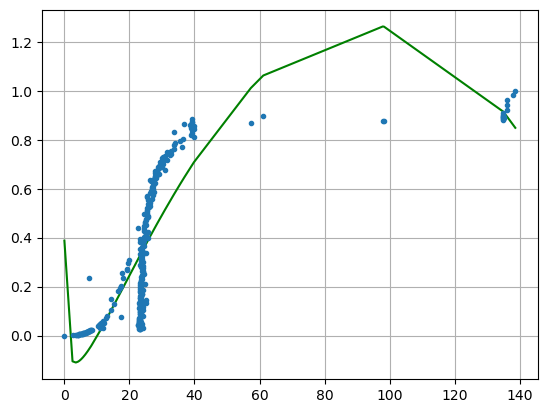

In [6]:
radii = []
acc = []
j = np.size(Mdot)
t = 0

for i in range(j):
    spa = Rstart[i]*u.cm.to(u.AU)
    spb = Mdot[i]
    radii.append(spa)
    acc.append(spb)
    t = t+1

acc = acc/acc[-1]

Mdarray = np.column_stack((radii, acc))
bfg = Mdarray[Mdarray[:,0].argsort()]

def Exp(x, A, B, C, D):
    y = A*np.log(x) + B*x**2 + C*x + D
    return y
def deriv_Exp(x, A, B, C):
    y = A/x + 2.*B*x + C
    return y

xdata = bfg[:, 0]
ydata = bfg[:, 1]

parameters, covariance = curve_fit(Exp, xdata, ydata)
print(parameters, xdata[-1])

fit_A = parameters[0]
fit_B = parameters[1]
fit_C = parameters[2]
fit_D = parameters[3]

fit_y = Exp(xdata, fit_A, fit_B, fit_C, fit_D)
plt.plot(xdata, fit_y, 'g-', label='fit')

xdata = bfg[:,0]
ydata = bfg[:,1]
plt.plot(xdata, ydata, '.', label='data')
plt.grid()
#plt.xlim(0, 20)
#plt.ylim(0, 0.5)


Comparing Rcrit_50au vs Rcrit_50au_wide

  Rcrit_50au: Reading data.0595.dbl.h5
  Rcrit_50au_wide: Reading data.0065.dbl.h5
  Rcrit_50au_wide: Reading data.0065.dbl.h5
  Saved: comparison_Rcrit_50au_vs_Rcrit_50au_wide.png
  Saved: comparison_Rcrit_50au_vs_Rcrit_50au_wide.png


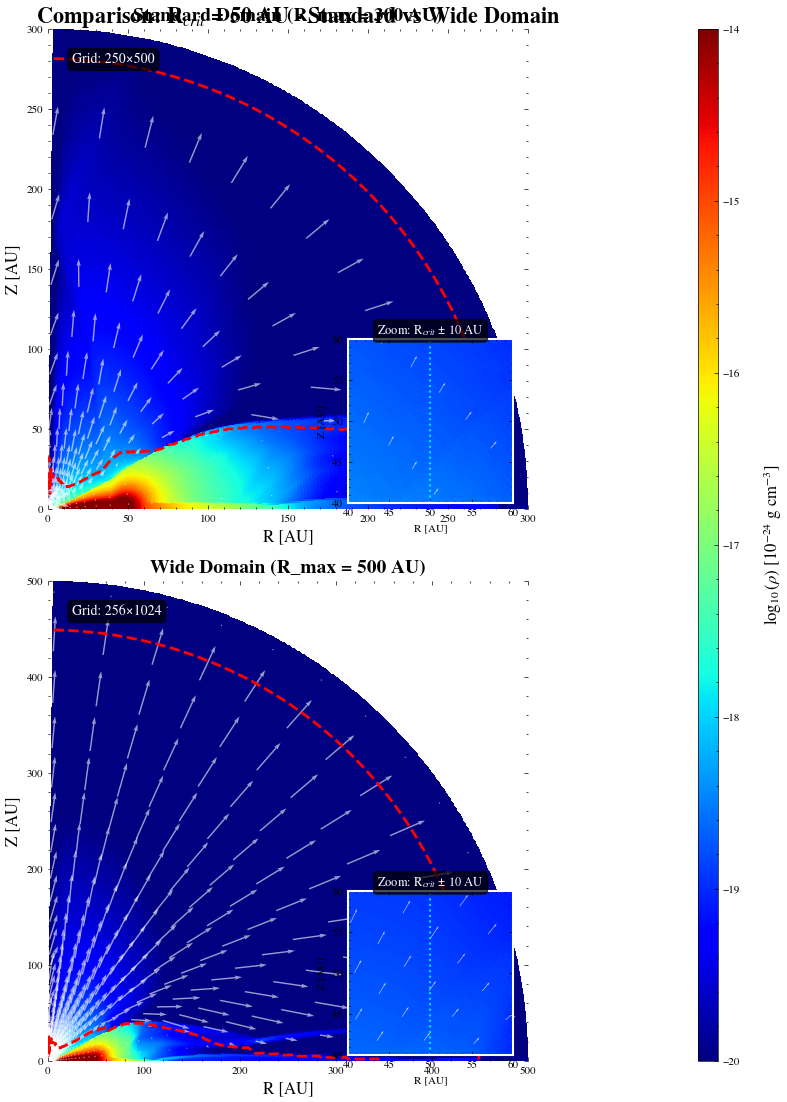


Comparing Rcrit_100au vs Rcrit_100au_wide

  Rcrit_100au: Reading data.0373.dbl.h5
  Rcrit_100au_wide: Reading data.0072.dbl.h5
  Rcrit_100au_wide: Reading data.0072.dbl.h5
  Saved: comparison_Rcrit_100au_vs_Rcrit_100au_wide.png
  Saved: comparison_Rcrit_100au_vs_Rcrit_100au_wide.png


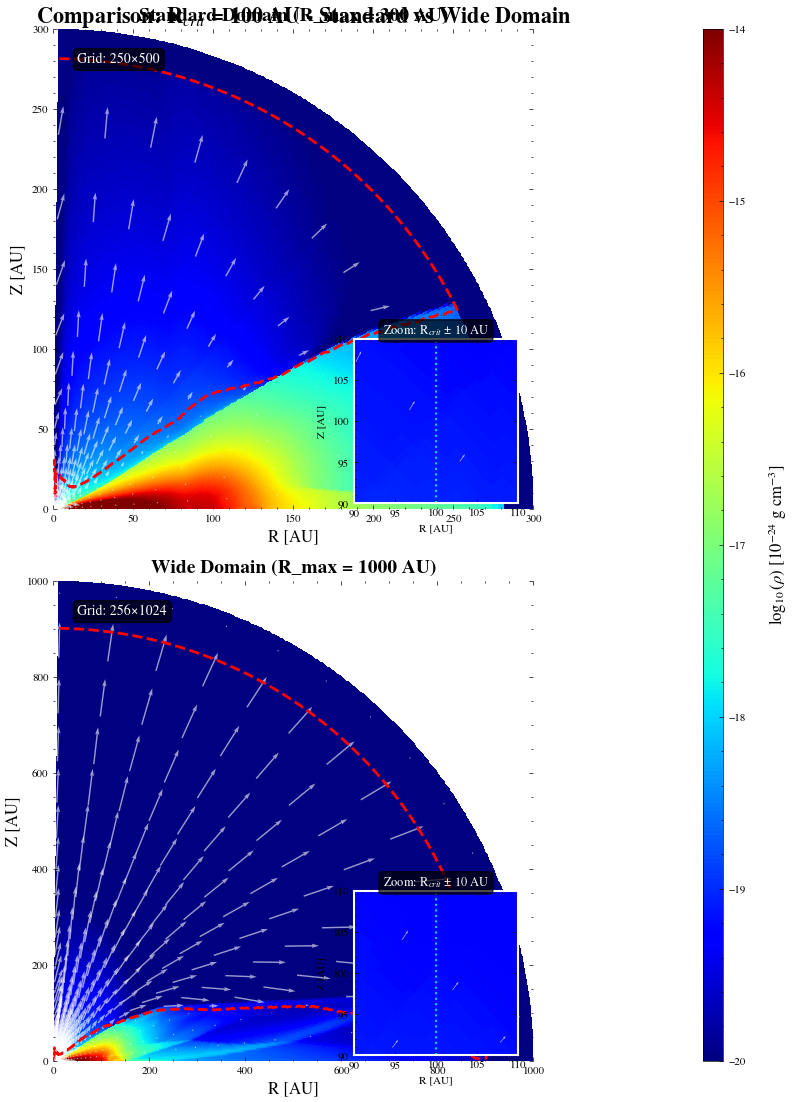


Comparing Rcrit_200au vs Rcrit_200au_wide

  Rcrit_200au: Reading data.0364.dbl.h5
  Rcrit_200au_wide: Reading data.0072.dbl.h5
  Saved: comparison_Rcrit_200au_vs_Rcrit_200au_wide.png
  Saved: comparison_Rcrit_200au_vs_Rcrit_200au_wide.png


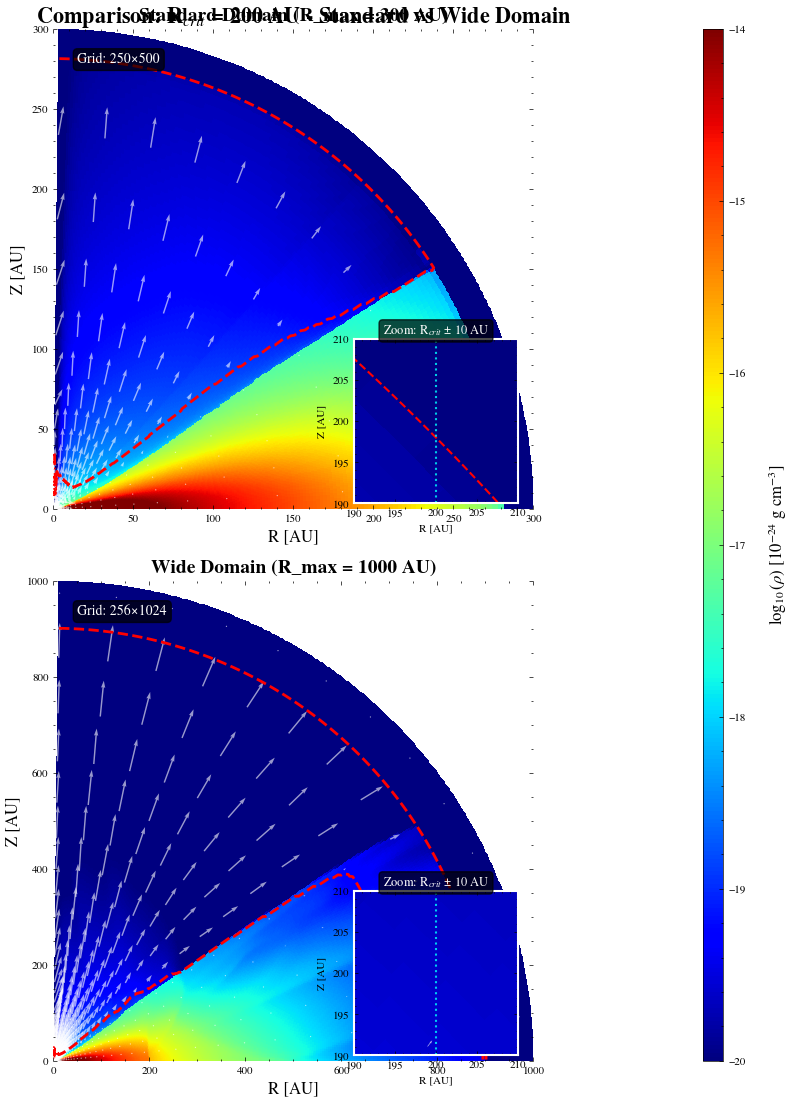


All comparisons completed!


In [11]:
# Compare standard vs wide domain runs for Rcrit_50au, 100au, and 200au
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from astropy import constants as const
import os
import glob
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

base_path = '/e/ocean1/users/picogna/Photoevaporation-OuterRadius-Project/PLUTO_runs/'

# Define run pairs to compare
run_pairs = [
    ('Rcrit_50au', 'Rcrit_50au_wide', 50, 500),
    ('Rcrit_100au', 'Rcrit_100au_wide', 100, 1000),
    ('Rcrit_200au', 'Rcrit_200au_wide', 200, 1000)
]

# Stellar mass
Mstar = 1.0 * const.M_sun

for run_std, run_wide, rcrit, xlim_wide in run_pairs:
    print(f"\n{'='*80}")
    print(f"Comparing {run_std} vs {run_wide}")
    print(f"{'='*80}\n")
    
    # Create figure with 2 rows (standard and wide) and 1 column
    fig, axes = plt.subplots(2, 1, figsize=(10, 12))
    fig.subplots_adjust(left=.1, bottom=.08, right=.88, top=.94, hspace=0.15)
    
    for idx, (run_name, xlim) in enumerate([(run_std, 300), (run_wide, xlim_wide)]):
        ax = axes[idx]
        
        # Read last output
        output_dir = os.path.join(base_path, run_name, 'out')
        os.chdir(output_dir)
        
        data_files = sorted(glob.glob('data.*.dbl.h5'))
        last_file = data_files[-1]
        
        print(f"  {run_name}: Reading {last_file}")
        
        # Read data
        grid_temp = read_grid(last_file)
        data_temp = read_data(last_file, grid_temp)
        
        # Convert to appropriate units
        X_AU = (grid_temp["X"]*u.cm).to(u.AU).value
        Z_AU = (grid_temp["Z"]*u.cm).to(u.AU).value
        vx_cms = data_temp["v_x"]
        vz_cms = data_temp["v_z"]
        vx_kms = (vx_cms*u.cm/u.s).to(u.km/u.s).value
        vz_kms = (vz_cms*u.cm/u.s).to(u.km/u.s).value
        
        # Calculate gravitationally unbound region
        v_total = np.sqrt(vx_cms**2 + vz_cms**2)
        R_grid = grid_temp["X"]
        Z_grid = grid_temp["Z"]
        r_distance = np.sqrt(R_grid**2 + Z_grid**2)
        v_escape = np.sqrt(2 * const.G.cgs.value * Mstar.cgs.value / r_distance)
        unbound_mask = v_total > v_escape
        
        # Downsample for vectors
        skip = 20
        
        # Set plot properties
        ax.set_xlim(0, xlim)
        ax.set_ylim(0, xlim)
        ax.set_aspect('equal')
        ax.set_xlabel('R [AU]', fontsize=12)
        ax.set_ylabel('Z [AU]', fontsize=12)
        
        # Add title
        domain_type = "Standard Domain" if idx == 0 else "Wide Domain"
        ax.set_title(f'{domain_type} (R_max = {xlim} AU)', fontsize=14, fontweight='bold')
        
        # Plot density
        valmin = -20
        valmax = -14
        labelplot = '$\\log_{10}(\\rho)$ [$10^{-24}$ g cm$^{-3}$]'
        plot = ax.pcolormesh(X_AU, Z_AU, np.log10(data_temp["density"]),
                           vmin=valmin, vmax=valmax, cmap=plt.cm.jet)
        
        # Add contour for gravitationally unbound region
        unbound_contour = ax.contour(X_AU, Z_AU, unbound_mask.astype(float), 
                                     levels=[0.5], linestyles='dashed', 
                                     colors='red', linewidths=2.0)
        
        # Add velocity vectors
        Q = ax.quiver(X_AU[::skip, ::skip], Z_AU[::skip, ::skip], 
                      vx_kms[::skip, ::skip], vz_kms[::skip, ::skip],
                      color='white', alpha=0.6, scale=300, width=0.003)
        
        # Add velocity scale legend
        ax.quiverkey(Q, 0.85, 0.95, 25, '25 km/s', labelpos='E', 
                     coordinates='axes', color='white', labelcolor='white',
                     fontproperties={'size': 10})
        
        # Add text with grid info
        grid_info = f"Grid: {grid_temp['X'].shape[0]}×{grid_temp['X'].shape[1]}"
        ax.text(0.05, 0.95, grid_info, transform=ax.transAxes,
                fontsize=10, verticalalignment='top', color='white',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
        
        # Add inset zoom around cut-off radius
        # Define zoom region: Rcrit ± 10 AU
        zoom_margin = 10  # AU
        r_min_zoom = max(0, rcrit - zoom_margin)
        r_max_zoom = rcrit + zoom_margin
        
        # Create inset axes
        axins = inset_axes(ax, width="35%", height="35%", loc='lower right',
                          bbox_to_anchor=(0, 0, 0.98, 0.98), bbox_transform=ax.transAxes)
        
        # Plot density in inset
        axins.pcolormesh(X_AU, Z_AU, np.log10(data_temp["density"]),
                        vmin=valmin, vmax=valmax, cmap=plt.cm.jet)
        
        # Add unbound contour in inset
        axins.contour(X_AU, Z_AU, unbound_mask.astype(float), 
                     levels=[0.5], linestyles='dashed', 
                     colors='red', linewidths=1.5)
        
        # Add velocity vectors in inset (higher resolution)
        skip_inset = 10
        axins.quiver(X_AU[::skip_inset, ::skip_inset], Z_AU[::skip_inset, ::skip_inset], 
                    vx_kms[::skip_inset, ::skip_inset], vz_kms[::skip_inset, ::skip_inset],
                    color='white', alpha=0.7, scale=150, width=0.004)
        
        # Set zoom limits
        axins.set_xlim(r_min_zoom, r_max_zoom)
        axins.set_ylim(r_min_zoom, r_max_zoom)
        axins.set_aspect('equal')
        
        # Add vertical line at Rcrit in inset
        axins.axvline(rcrit, color='cyan', linestyle=':', linewidth=1.5, alpha=0.8)
        
        # Style inset
        axins.tick_params(labelsize=8)
        axins.set_xlabel('R [AU]', fontsize=8)
        axins.set_ylabel('Z [AU]', fontsize=8)
        
        # Add title to inset
        axins.set_title(f'Zoom: R$_{{crit}}$ ± {zoom_margin} AU', fontsize=9, 
                       color='white', pad=3, 
                       bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
        
        # Make inset spines white for visibility
        for spine in axins.spines.values():
            spine.set_edgecolor('white')
            spine.set_linewidth(1.5)
        
        # Clean up main plot spines
        ax.tick_params(top='off', bottom='on', left='on', right='off')
        for spine in ax.spines.values():
            spine.set_visible(False)
    
    # Add single colorbar on the right side
    cbar_ax = fig.add_axes([0.90, 0.08, 0.02, 0.86])
    cbar = fig.colorbar(plot, cax=cbar_ax, orientation='vertical')
    cbar.set_label(labelplot, fontsize=12, labelpad=15)
    
    # Overall title
    plt.suptitle(f'Comparison: R$_{{crit}}$ = {rcrit} AU - Standard vs Wide Domain', 
                 fontsize=16, fontweight='bold', y=0.96)
    
    # Save figure
    save_name = f'comparison_{run_std}_vs_{run_wide}.png'
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    print(f"  Saved: {save_name}")
    
    plt.show()
    plt.close(fig)

print(f"\n{'='*80}")
print("All comparisons completed!")
print(f"{'='*80}")